In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# import sys
# sys.path.append("../../../")
# from xThreat import xThreat

from xThreat import xThreat

In [2]:
n_x = 16
n_y = 12

In [ ]:
xT_true_16x12 = xThreat.load_from_pickle(f'../../../data-storage/models/ground-truth/xt-full-data-n_x{n_x}-n_y{n_y}.pickle')
xT_16x12_N_3_350_000 = xThreat.load_from_pickle('../../../data-storage/models/resampled/xT_16x12_N_3_350_000.pkl') # Created in rules_of_thumb.ipynb

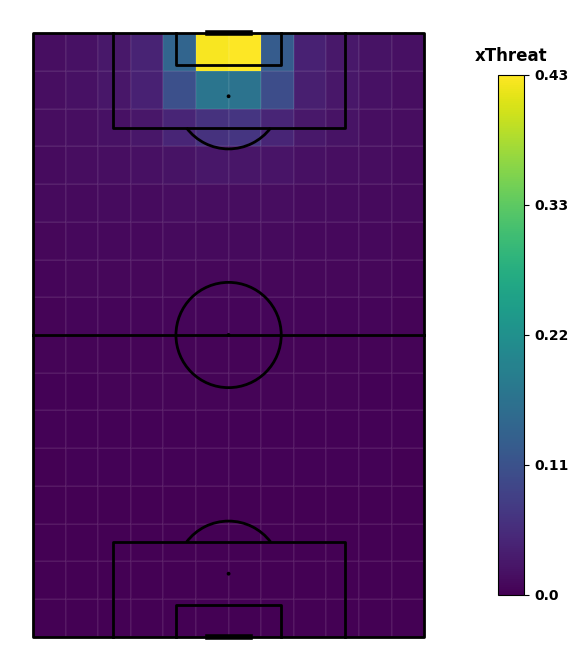

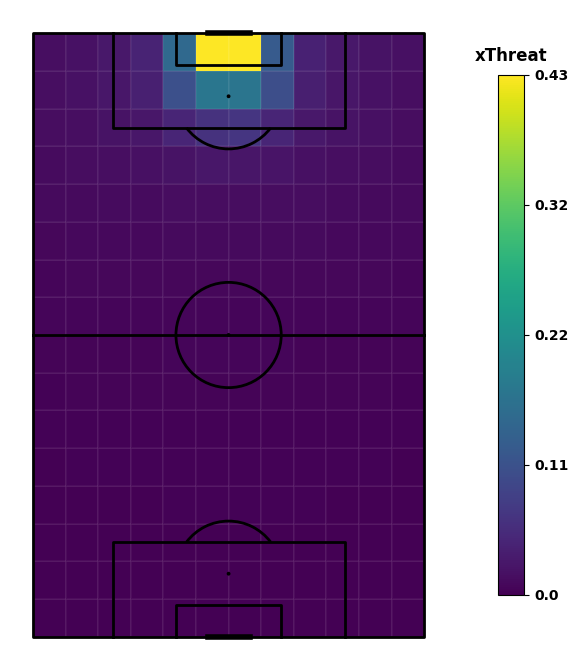

Estimation error is 0.005772050609179069


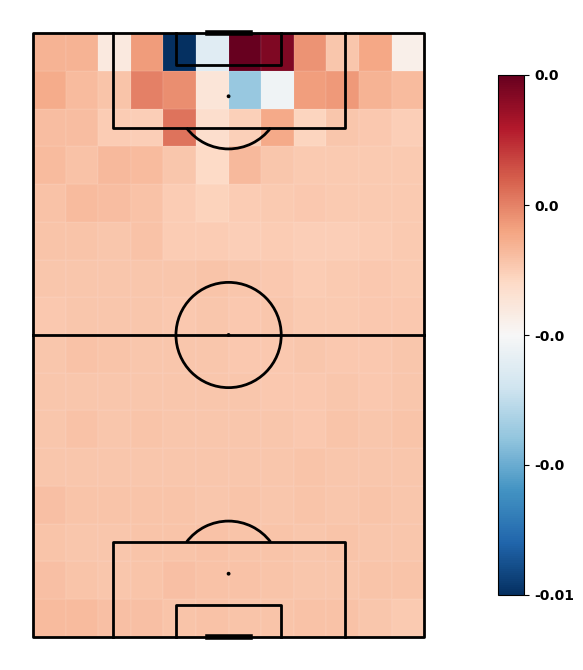

In [4]:
# Show the xT surfaces
xT_true_16x12.plot_xThreat(cmap='viridis', edgecolors='white', edge_alpha=0.05, linewidths=0.01)
xT_16x12_N_3_350_000.plot_xThreat(cmap='viridis', edgecolors='white', edge_alpha=0.05, linewidths=0.01)

# Show the difference between the two xT surfaces
xT_diff = xT_true_16x12.xT - xT_16x12_N_3_350_000.xT
xT_true_16x12.plot_pitch_heatmap(xT_diff, cmap='RdBu_r', edgecolors='white', edge_alpha=0.05, linewidths=0.01)
print(f"Estimation error is {np.max(np.abs(xT_diff))}")


The plots show that the error seems small. Indeed, the estimation error is really small as we can see by comparing it to the ground truth. This indicates that the estimation error is approximately 0.0058, significantly smaller than $EE_{max}=0.0192$. The estimated model is thus for sure of sufficient quality.

In [ ]:
df_euros = pd.read_parquet('../../../data-storage/preprocessed/euros_2020.parquet')

In [6]:
df_euros.describe()

,x,y,possession,possession_length,chain_length,match_id,period,player_id,shot_statsbomb_xg,under_pressure,next_x,next_y,next_under_pressure,next_team_id,next_player_id
count,92654.000000,92654.000000,92654.000000,92654.000000,92654.000000,9.265400e+04,92654.000000,92654.000000,619.000000,20416.0,92654.000000,92654.000000,20407.0,92654.000000,92654.000000
mean,51.333875,33.650458,89.303743,12.809172,8.329559,3.790811e+06,1.574417,10128.393291,0.140505,1.0,51.345598,33.648096,1.0,886.433538,10129.786906
std,23.291350,19.858639,55.170866,13.628198,10.101545,2.917399e+03,0.660055,8483.507971,0.196433,0.0,23.296198,19.857529,0.0,273.628451,8485.351214
min,0.350000,0.085000,2.000000,0.000000,0.000000,3.788741e+06,1.000000,2954.000000,0.004871,1.0,0.350000,0.085000,1.0,768.000000,2954.000000
25%,35.087500,16.171250,43.000000,3.000000,1.000000,3.788754e+06,1.000000,4870.000000,0.035180,1.0,35.175000,16.235000,1.0,772.000000,4870.000000
50%,50.925000,33.405000,85.000000,8.000000,5.000000,3.788767e+06,2.000000,6954.000000,0.060380,1.0,50.925000,33.405000,1.0,785.000000,6954.000000
75%,68.250000,51.085000,131.000000,18.000000,12.000000,3.794688e+06,2.000000,11514.000000,0.139786,1.0,68.250000,51.085000,1.0,912.000000,11514.000000
max,104.650000,67.915000,275.000000,119.000000,103.000000,3.795506e+06,5.000000,73852.000000,0.963011,1.0,104.650000,67.915000,1.0,2358.000000,73852.000000


# Filter on players with at least 300 minutes

## Find minutes per player

In [7]:
player_ids = df_euros['player_id'].unique().tolist()
position_mapping = {
    'Goalkeeper': 'Goalkeeper',
    'Right Back': 'Defender', 'Left Back': 'Defender', 'Center Back': 'Defender', 'Right Center Back': 'Defender', 'Left Center Back': 'Defender',
    'Right Wing Back': 'Defender', 'Left Wing Back': 'Defender', 
    'Center Defensive Midfield': 'Midfielder', 'Left Defensive Midfield': 'Midfielder', 'Right Defensive Midfield': 'Midfielder',
    'Central Midfield': 'Midfielder', 
    'Center Attacking Midfield': 'Midfielder', 'Right Attacking Midfield': 'Midfielder', 'Left Attacking Midfield': 'Midfielder',
    'Left Center Forward': 'Attacker', 'Right Center Forward': 'Attacker',
    'Right Midfield': 'Midfielder', 'Left Midfield': 'Midfielder', 'Right Center Midfield': 'Midfielder', 'Left Center Midfield': 'Midfielder',
    'Right Wing': 'Attacker', 'Left Wing': 'Attacker', 'Center Forward': 'Attacker', 'Second Striker': 'Attacker'
}

In [8]:
# Get all competitions and find UEFA Euro 2020
competitions = sb.competitions()
euro_2020 = competitions[
    (competitions['competition_name'] == 'UEFA Euro') & (competitions['season_name'] == '2020')
]
competition_id = euro_2020.iloc[0]['competition_id']
season_id = euro_2020.iloc[0]['season_id']

# Get all matches
matches = sb.matches(competition_id=competition_id, season_id=season_id)
match_ids = matches['match_id'].tolist()

# Dictionary to store player minutes
player_minutes = {}

# Dictionary to store player positions
player_positions = {}

# Dictionary to store player names for each id
player_ids = {}

# Loop through each match
for match_id in match_ids:
    events = sb.events(match_id)
    
    # Get match duration (accounting for extra time)
    max_minute = events['minute'].max()

    # Track player substitutions
    player_in_times = {}  # {player_name: entry_minute}
    player_out_times = {} # {player_name: exit_minute}

    for _, event in events.iterrows():
        if event['type'] == 'Substitution':
            player_off = event['player']
            player_on = event['substitution_replacement']
            minute = event['minute']

            if player_off:
                player_out_times[player_off] = minute
            if player_on:
                player_in_times[player_on] = minute

    # Calculate minutes for all players
    for player in events['player'].dropna().unique():
        start_minute = player_in_times.get(player, 0)  # Defaults to starting lineup (0 min)
        end_minute = player_out_times.get(player, max_minute)  # Defaults to full game

        minutes_played = end_minute - start_minute
        player_minutes[player] = player_minutes.get(player, 0) + minutes_played

    # Get lineup data for this match
    lineup_data = sb.lineups(match_id)

    # Extract player positions (lineup_data is a dictionary of DataFrames)
    for team_name, lineup_df in lineup_data.items():
        for _, player in lineup_df.iterrows():
            player_name = player['player_name']
            player_id = player['player_id']
            player_ids[player_name] = player_id

            game_player_positions = player_positions.get(player_name, {'Goalkeeper': 0, 'Defender': 0, 'Midfielder': 0, 'Attacker': 0})
            for position in player['positions']:
                game_player_positions[position_mapping[position['position']]] += 1
                
            player_positions[player_name] = game_player_positions

# Convert minutes to DataFrame
players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])

player_ids = pd.DataFrame(player_ids.items(), columns = ['Player', 'player_id'])

# Convert positions to DataFrame
player_names = player_positions.keys()
goalkeeper, defender, midfielder, attacker = [], [], [], []
for player_name in player_names:
    goalkeeper.append(player_positions[player_name]['Goalkeeper'])
    defender.append(player_positions[player_name]['Defender'])
    midfielder.append(player_positions[player_name]['Midfielder'])
    attacker.append(player_positions[player_name]['Attacker'])

positions_df = pd.DataFrame({
    'Player': player_names,
    'goalkeeper': goalkeeper,
    'defender': defender,
    'midfielder': midfielder,
    'attacker': attacker,
})
positions_df["main_position"] = positions_df[["goalkeeper", "defender", "midfielder", "attacker"]].idxmax(axis=1)


# Merge DataFrames
players_df = players_df.merge(positions_df, on='Player', how='left')
players_df = players_df.merge(player_ids, on='Player', how='left')

# Filter for players with at least 300 minutes
filtered_players = players_df[players_df['Minutes'] >= 300]


In [9]:
filtered_players.head()

,Player,Minutes,goalkeeper,defender,midfielder,attacker,main_position,player_id
8,Vitalii Mykolenko,363,0,5,0,0,defender,20827
9,Oleksandr Karavaev,496,0,6,0,0,defender,31900
10,Illia Zabarnyi,496,0,5,0,0,defender,39136
11,Mykola Matvienko,401,0,5,0,0,defender,18617
12,Oleksandr Zinchenko,496,0,1,4,1,midfielder,3575


## Distribution of minutes over players

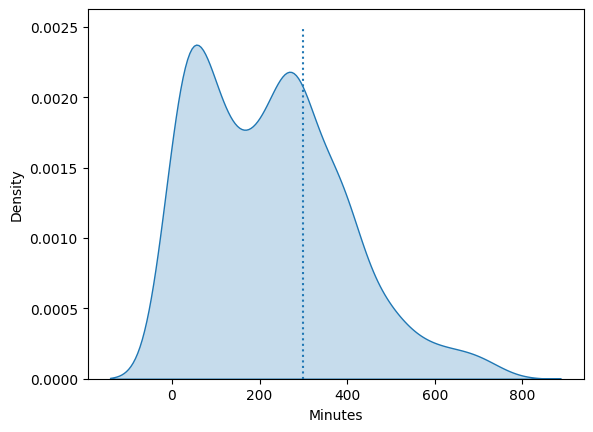

In [10]:
ax = sns.kdeplot(data=players_df, x='Minutes', fill=True)
ax.plot([300, 300], [0,0.0025], ":")
plt.show()

# Filter on players with at least 300 minutes

In [11]:
filtered_player_ids = filtered_players['player_id']
mask = df_euros['player_id'].isin(filtered_player_ids)
df_euros_filtered = df_euros[mask].copy()
df_euros_filtered.head()

,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,shot_statsbomb_xg,pass_height,under_pressure,position,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id
index,,,,,,,,,,,,,,,,,,,,,
2088,13.8250,6.375,True,3,0,0,True,3788741,4cbd1088-1580-43f5-8b09-58efabb753ff,1,...,NaN,None,NaN,Left Center Back,Pass,2.8875,10.795,NaN,914.0,6954.0
9,2.8875,10.795,True,3,2,1,False,3788741,bfcfd5ad-1dda-44c9-9f3d-9b33b59983a6,1,...,NaN,Ground Pass,NaN,Left Center Back,Carry,6.9125,30.770,NaN,914.0,7036.0
2089,6.9125,30.770,True,3,3,2,False,3788741,58ef2997-552a-4d3e-854a-cf863f9f5b71,1,...,NaN,None,NaN,Goalkeeper,Pass,7.9625,33.065,NaN,914.0,7036.0
10,7.9625,33.065,True,3,4,3,False,3788741,14604dfa-65b1-40c0-a11e-7c6b037806c0,1,...,NaN,Ground Pass,NaN,Goalkeeper,Carry,17.2375,40.715,NaN,914.0,7173.0
2090,17.2375,40.715,True,3,5,4,False,3788741,5eae5d7a-59cb-42e0-bfc0-c5a2e80493ee,1,...,NaN,None,NaN,Right Center Back,Pass,25.2000,42.415,NaN,914.0,7173.0


# Apply resampled model 16x12

## Prepare data

In [13]:
# Get xT values
df_euros_filtered['shot'] = ~df_euros_filtered['shot_outcome'].isna()
df_euros_filtered['goal'] = df_euros_filtered['shot_outcome'] == 'Goal'
df_euros_filtered = xT_16x12_N_3_350_000.quantify_action_quality(df_euros_filtered)

In [14]:
# Filter for positive xT actions
df_positive = df_euros_filtered[df_euros_filtered['action_xT'] > 0]

# Calculate action xT per player
player_xT_df = df_positive.groupby('player_id').agg(
    action_xT_sum=('action_xT', 'sum'),
    action_count=('action_xT', 'count'),
).reset_index()

# Add information like player name, minutes, and position
player_xT_df = player_xT_df.merge(filtered_players[['player_id', 'Player', 'Minutes', 'main_position']], on='player_id', how='left')

# Calculate action xT per 90 minutes
player_xT_df['action_xT_per_90'] = player_xT_df['action_xT_sum'] / player_xT_df['Minutes'] * 90

# Sort players by action xT
player_xT_df = player_xT_df.sort_values('action_xT_per_90')

# Filter midfielders
midfielder_xT_df = player_xT_df[player_xT_df['main_position'] == 'midfielder'].sort_values('action_xT_per_90')

midfielder_xT_df

,player_id,action_xT_sum,action_count,Player,Minutes,main_position,action_xT_per_90
120,16514.0,0.231840,117,Serhii Sydorchuk,384,midfielder,0.054338
69,5617.0,0.281729,56,Sebastian Larsson,383,midfielder,0.066203
72,5624.0,0.337367,76,Albin Ekdal,402,midfielder,0.075530
40,4870.0,0.407988,154,Tomáš Souček,471,midfielder,0.077959
38,4706.0,0.619237,183,Kalvin Phillips,685,midfielder,0.081360
30,3943.0,0.529767,248,Declan Rice,541,midfielder,0.088131
110,10931.0,0.344966,96,Joe Allen,349,midfielder,0.088960
75,5642.0,0.322181,146,Axel Witsel,322,midfielder,0.090050
33,3961.0,0.350530,189,N'Golo Kanté,317,midfielder,0.099519
81,6983.0,0.599242,171,Remo Freuler,526,midfielder,0.102532


## Beeswarmplot midfielders

In [16]:
# Determine quartile thresholds
q1 = midfielder_xT_df['action_xT_per_90'].quantile(0.25)
q2 = midfielder_xT_df['action_xT_per_90'].quantile(0.5)
q3 = midfielder_xT_df['action_xT_per_90'].quantile(0.75)

# Assign colors based on quartiles
def assign_quartile(value):
    if value <= q1:
        return 'Q1'
    elif value <= q2:
        return 'Q2'
    elif value <= q3:
        return 'Q3'
    else:
        return 'Q4'
    
cm = matplotlib.colormaps.get_cmap('RdYlGn')
palette_quartile = {
           'Q1': cm(0.125),
           'Q2': cm(0.375),
           'Q3': cm(0.625),
           'Q4': cm(0.875),
           }

print(f"There are {midfielder_xT_df['Player'].nunique()} unique midfielders in this data set.")
print(f"Lowest xT/90 midfielder: {midfielder_xT_df.iloc[0]['Player']} with {midfielder_xT_df.iloc[0]['action_xT_per_90']:.4f} xT/90")
print(f"Highest xT/90 midfielder: {midfielder_xT_df.iloc[-1]['Player']} with {midfielder_xT_df.iloc[-1]['action_xT_per_90']:.4f} xT/90")
midfielder_xT_df['Quartile'] = midfielder_xT_df['action_xT_per_90'].apply(assign_quartile)

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(midfielder_xT_df) // 4, len(midfielder_xT_df) // 2, 3 * len(midfielder_xT_df) // 4, len(midfielder_xT_df) - 4, len(midfielder_xT_df) - 3, len(midfielder_xT_df) - 2, len(midfielder_xT_df) - 1]
key_players = midfielder_xT_df.iloc[key_indices]

There are 41 unique midfielders in this data set.
Lowest xT/90 midfielder: Serhii Sydorchuk with 0.0543 xT/90
Highest xT/90 midfielder: Kai Havertz with 0.3342 xT/90


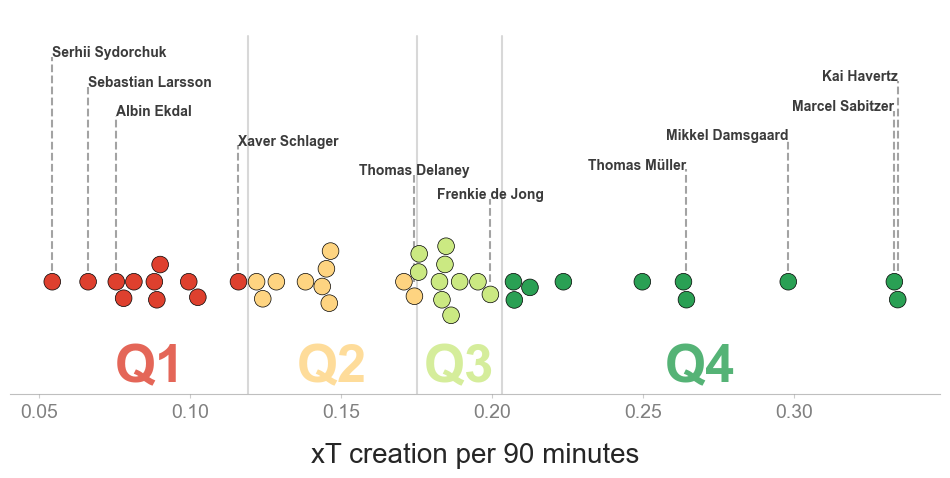

In [ ]:
sns.set_theme(style="white")


# ---- Compute quartile boundaries between points ----
x_sorted = np.sort(midfielder_xT_df['action_xT_per_90'].values)
n = len(x_sorted)

# Indices where quartile splits occur
i1 = int(0.25 * n)
i2 = int(0.50 * n)
i3 = int(0.75 * n)

# Boundary positions: midpoint between adjacent points
b1 = (x_sorted[i1] + x_sorted[i1+1]) / 2
b2 = (x_sorted[i2] + x_sorted[i2+1]) / 2
b3 = (x_sorted[i3] + x_sorted[i3+1]) / 2


plt.figure(figsize=(12, 5))
ax = sns.swarmplot(
    x=midfielder_xT_df['action_xT_per_90'],
    orient='h',
    size=12,
    hue=midfielder_xT_df['Quartile'],
    palette=palette_quartile,
    edgecolor='black',
    linewidth=0.5
)

ax.grid(False)

# ---- Quartile boundaries (vertical lines only) ----
eps = 0.0008
for x in [b1, b2, b3]:
    ax.axvline(
        x=x,
        color='grey',
        alpha=0.3,
        linewidth=1.5,
        zorder=0,
        ymax=0.93,
    )


# ---- Quartile annotations (no background, colored text) ----

quartile_bounds = [
    (x_sorted.min(), b1, 'Q1'),
    (b1, b2, 'Q2'),
    (b2, b3, 'Q3'),
    (b3, x_sorted.max(), 'Q4'),
]

for left, right, q in quartile_bounds:
    ax.text(
        (left + right) / 2,
        0.07,
        q,
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='center',
        fontsize=38,
        fontweight='bold',
        color=palette_quartile[q],
        alpha=0.8,
        zorder=0
    )

# ---- Annotate selected players ----
y_positions = np.abs(np.linspace(-0.09, 0.075, len(key_players))) + 0.05
x_mid = midfielder_xT_df['action_xT_per_90'].median()

n_keys = len(key_players)
middle_indices = {n_keys // 2 - 1, n_keys // 2}

for i, (_, row) in enumerate(key_players.iterrows()):
    x = row['action_xT_per_90']

    ha = 'right' if x > x_mid else 'left'
    if i in middle_indices:
        ha = 'center'

    ax.plot(
        [x, x],
        [0, y_positions[i]],
        'k--',
        alpha=0.4
    )

    ax.text(
        x,
        y_positions[i] + 0.003,
        row['Player'],
        fontsize=10,
        ha=ha,
        va='center',
        fontweight='bold',
        alpha=0.9
    )

# ---- Axes styling ----
ax.set_xlabel('xT creation per 90 minutes', fontsize=20, labelpad=15)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['bottom'].set_alpha(0.5)

ax.tick_params(
    axis='x',
    which='both',
    bottom=True,
    top=False,
    labelbottom=True,
    length=3,
    width=0.8,
    color='grey',
    labelsize=14,
    labelcolor='grey'
)

for tick in ax.xaxis.get_major_ticks():
    tick.tick1line.set_alpha(0.4)
    tick.tick2line.set_alpha(0.4)

ax.set_ylim(-0.07, 0.17)

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.show()

## Beeswarmplot all players

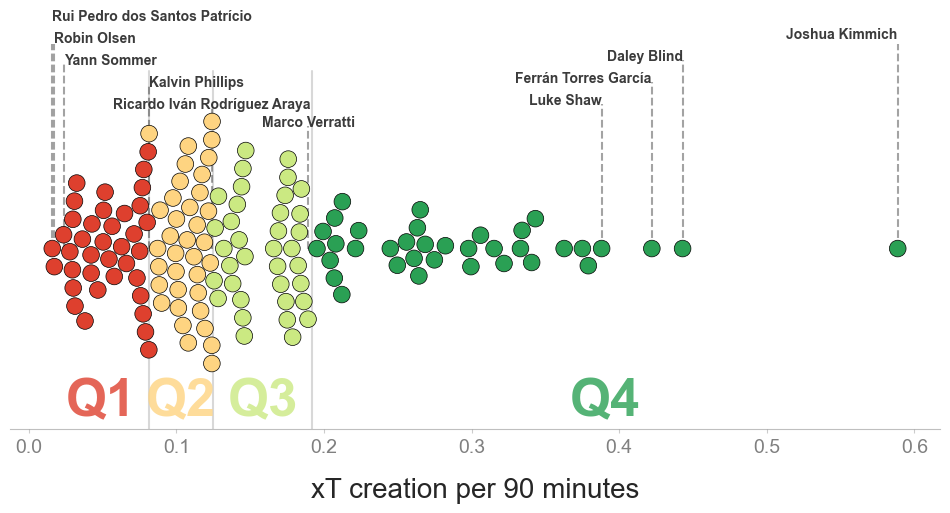

In [ ]:
sns.set_theme(style="white")

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df) // 4, len(player_xT_df) // 2, 3 * len(player_xT_df) // 4, len(player_xT_df) - 4, len(player_xT_df) - 3, len(player_xT_df) - 2, len(player_xT_df) - 1]
key_players = player_xT_df.iloc[key_indices]


# ---- Compute quartile boundaries between points ----
x_sorted = np.sort(player_xT_df['action_xT_per_90'].values)
n = len(x_sorted)

# Indices where quartile splits occur
i1 = int(0.25 * n)
i2 = int(0.50 * n)
i3 = int(0.75 * n)

# Boundary positions: midpoint between adjacent points
b1 = (x_sorted[i1] + x_sorted[i1+1]) / 2
b2 = (x_sorted[i2] + x_sorted[i2+1]) / 2
b3 = (x_sorted[i3] + x_sorted[i3+1]) / 2


plt.figure(figsize=(12, 5))
ax = sns.swarmplot(
    x=player_xT_df['action_xT_per_90'],
    orient='h',
    size=12,
    hue=player_xT_df['Quartile'],
    palette=palette_quartile,
    edgecolor='black',
    linewidth=0.5
)

ax.grid(False)

# ---- Quartile boundaries (vertical lines only) ----
eps = 0.0008
for x in [b1, b2, b3]:
    ax.axvline(
        x=x,
        color='grey',
        alpha=0.3,
        linewidth=1.5,
        zorder=0,
        ymax=0.93,
    )


# ---- Quartile annotations (no background, colored text) ----

quartile_bounds = [
    (x_sorted.min(), b1, 'Q1'),
    (b1, b2, 'Q2'),
    (b2, b3, 'Q3'),
    (b3, x_sorted.max(), 'Q4'),
]

for left, right, q in quartile_bounds:
    ax.text(
        (left + right) / 2,
        0.07,
        q,
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='center',
        fontsize=38,
        fontweight='bold',
        color=palette_quartile[q],
        alpha=0.8,
        zorder=0
    )

# ---- Annotate selected players ----
y_positions = np.abs(np.linspace(-0.09, 0.075, len(key_players))) + 0.10
x_mid = player_xT_df['action_xT_per_90'].median()

n_keys = len(key_players)
middle_indices = {n_keys // 2 - 1, n_keys // 2}

for i, (_, row) in enumerate(key_players.iterrows()):
    x = row['action_xT_per_90']

    ha = 'right' if x > x_mid else 'left'
    if i in middle_indices:
        ha = 'center'

    ax.plot(
        [x, x],
        [0, y_positions[i]],
        'k--',
        alpha=0.4
    )

    ax.text(
        x,
        y_positions[i] + 0.003,
        row['Player'],
        fontsize=10,
        ha=ha,
        va='center',
        fontweight='bold',
        alpha=0.9
    )

# ---- Axes styling ----
ax.set_xlabel('xT creation per 90 minutes', fontsize=20, labelpad=15)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('grey')
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['bottom'].set_alpha(0.5)

ax.tick_params(
    axis='x',
    which='both',
    bottom=True,
    top=False,
    labelbottom=True,
    length=3,
    width=0.8,
    color='grey',
    labelsize=14,
    labelcolor='grey'
)

for tick in ax.xaxis.get_major_ticks():
    tick.tick1line.set_alpha(0.4)
    tick.tick2line.set_alpha(0.4)

ax.set_ylim(-0.15, 0.17)

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.show()